Analysis of the different model used

LINEAR REGRESSION (model 1):

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0,str(project_root))
print(sys.path[:3])


['/Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction', '/opt/anaconda3/envs/air-quality/lib/python312.zip', '/opt/anaconda3/envs/air-quality/lib/python3.12']


In [2]:
import src

print(src)
print(src.__file__)

<module 'src' from '/Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction/src/__init__.py'>
/Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction/src/__init__.py


In [3]:
from src.load_data import load_data
from src.preprocessing import X_train, X_validation, X_test, y_train, y_validation, y_test
from models.linear_regression import train_model, evaluate_model
import matplotlib.pyplot as plt
linear_model = train_model(X_train, y_train)
#to evaluate the model we will use 3 metrics: MAE, RMSE, and R2
y_validation_pred, mae, rmse, r2 = evaluate_model(linear_model, X_validation, y_validation)


In [4]:
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)
print("Validation R²:", r2)
print(
    "Actual PM2.5 range:",
    y_validation.min(),
    "→",
    y_validation.max()
)

print(
    "Predicted PM2.5 range:",
    y_validation_pred.min(),
    "→",
    y_validation_pred.max()
)

Validation MAE: 41.09320701468777
Validation RMSE: 56.56348111665171
Validation R²: 0.35146995936551784
Actual PM2.5 range: 3.0 → 999.0
Predicted PM2.5 range: -110.06736543460806 → 250.39355571771762


we can see that linear regression isn't able to represent extreme pollution values. Also it diplays values negative which has no physical meaning.

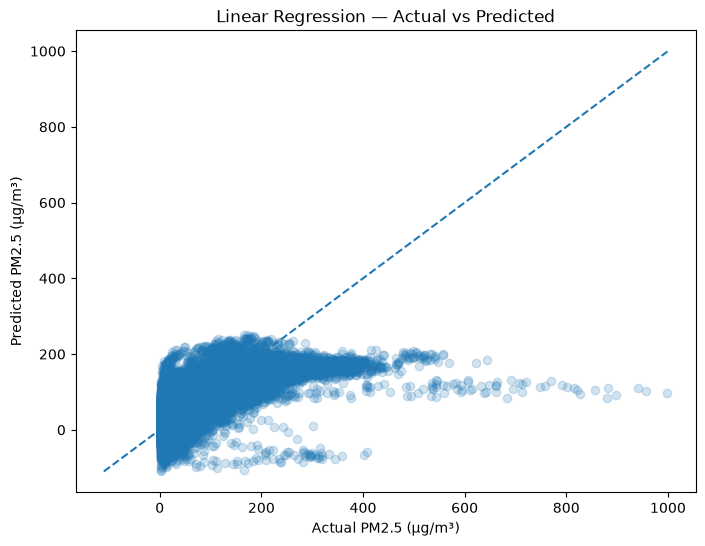

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    y_validation_pred,
    alpha=0.2
)

min_value = min(
    y_validation.min(),
    y_validation_pred.min()
)

max_value = max(
    y_validation.max(),
    y_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

LINEAR REGRESSION (model 2)

In [6]:
from src.preprocessing import X_train_pollution, X_validation_pollution, X_test_pollution, y_train_pollution, y_validation_pollution, y_test_pollution
linear_model_pollution = train_model(X_train_pollution, y_train_pollution)
y_validation_pollution_pred, mae_pollution, rmse_pollution, r2_pollution = evaluate_model(linear_model_pollution, X_validation_pollution, y_validation_pollution)

In [7]:
print("Validation MAE (Pollution):", mae_pollution)
print("Validation RMSE (Pollution):", rmse_pollution)
print("Validation R² (Pollution):", r2_pollution)
print(
    "Actual PM2.5 range:",
    y_validation_pollution.min(),
    "→",
    y_validation_pollution.max()
)
print(
    "Predicted PM2.5 range:",
    y_validation_pollution_pred.min(),
    "→",
    y_validation_pollution_pred.max()
)

Validation MAE (Pollution): 18.451862670719148
Validation RMSE (Pollution): 27.84380334172877
Validation R² (Pollution): 0.8388459962774704
Actual PM2.5 range: 3.0 → 821.0
Predicted PM2.5 range: -54.54330427706759 → 542.5041246882179


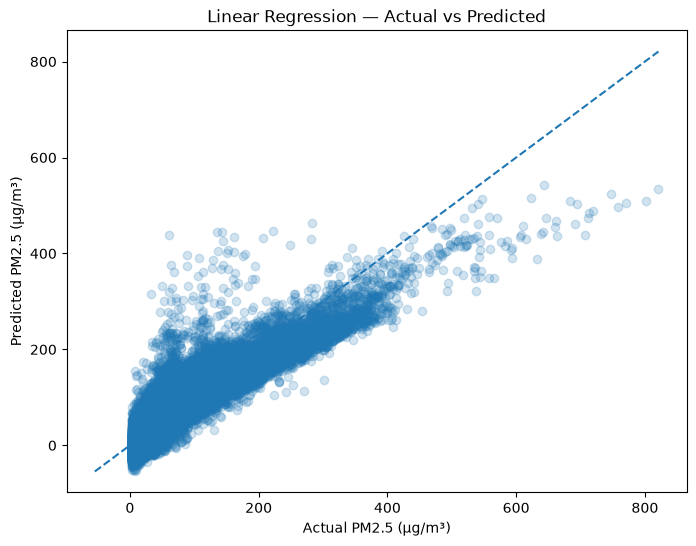

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation_pollution,
    y_validation_pollution_pred,
    alpha=0.2
)

min_value = min(
    y_validation_pollution.min(),
    y_validation_pollution_pred.min()
)

max_value = max(
    y_validation_pollution.max(),
    y_validation_pollution_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

Controlled comparison of the 2 model on the same restrictive data set (the one of model 2)

In [9]:
from src.preprocessing import X_train_common, X_validation_common, y_train_common, y_validation_common, X_train_common_pollution, X_validation_common_pollution, y_train_common_pollution, y_validation_common_pollution
linear_weather_common = train_model(X_train_common,y_train_common)
y_weather_validation,mae_weather_common,rmse_weather_common,r2_weather_common = evaluate_model(linear_weather_common,X_validation_common,y_validation_common)

In [10]:
print("Weather-only model:")
print("MAE:", mae_weather_common)
print("RMSE:", rmse_weather_common)
print("R²:", r2_weather_common)
print((
    "Predicted PM2.5 range:",
    y_weather_validation.min(),
    "→",
    y_weather_validation.max()
))

Weather-only model:
MAE: 40.67222007775052
RMSE: 54.92028957203642
R²: 0.37302587063127823
('Predicted PM2.5 range:', np.float64(-108.89566815830335), '→', np.float64(248.4766189265613))


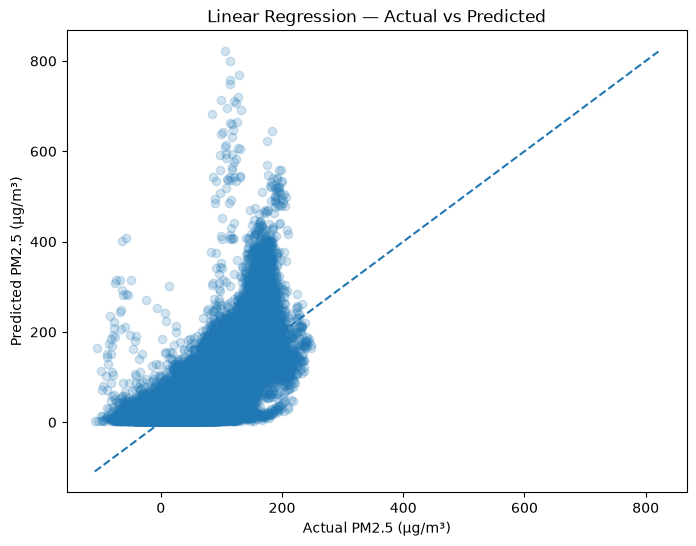

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_weather_validation,
    y_validation_common,
    alpha=0.2
)

min_value = min(
    y_weather_validation.min(),
    y_validation_common.min()
)

max_value = max(
    y_weather_validation.max(),
    y_validation_common.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

In [12]:
linear_pollution_model = train_model(X_train_common_pollution,y_train_common_pollution)
y_pollution_validation_pred,mae_pollution_common,rmse_pollution_common,r2_pollution_common = evaluate_model(linear_pollution_model,X_validation_common_pollution,y_validation_common_pollution)

In [13]:
print("Weather-pollution model:")
print("MAE:", mae_pollution_common)
print("RMSE:", rmse_pollution_common)
print("R²:", r2_pollution_common)
print((
    "Predicted PM2.5 range:",
    y_pollution_validation_pred.min(),
    "→",
    y_pollution_validation_pred.max()
))

Weather-pollution model:
MAE: 18.451862670719148
RMSE: 27.84380334172877
R²: 0.8388459962774704
('Predicted PM2.5 range:', np.float64(-54.54330427706759), '→', np.float64(542.5041246882179))


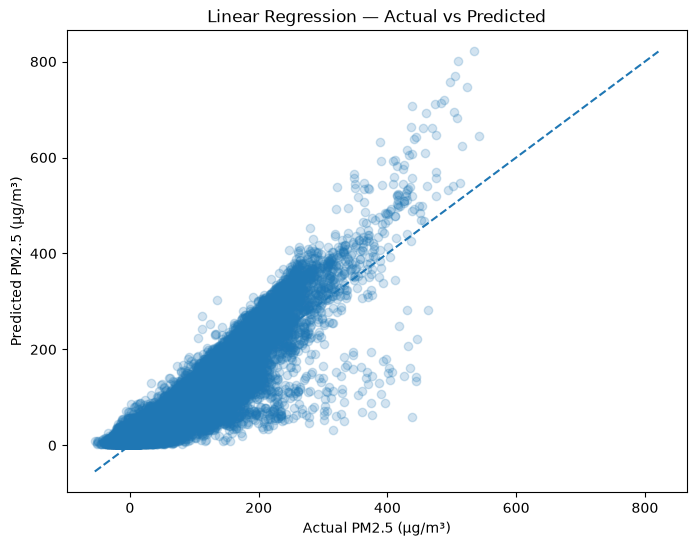

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pollution_validation_pred,
    y_validation_common_pollution,
    alpha=0.2
)

min_value = min(
    y_pollution_validation_pred.min(),
    y_validation_common_pollution.min()
)

max_value = max(
    y_pollution_validation_pred.max(),
    y_validation_common_pollution.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

Improvement thanks to the pollution data:

In [15]:
rmse_improvement = (
    (rmse_weather_common - rmse_pollution_common)
    / rmse_weather_common
    * 100
)

mae_improvement = (
    (mae_weather_common - mae_pollution_common)
    / mae_weather_common
    * 100
)

print("RMSE improvement:", rmse_improvement, "%")
print("MAE improvement:", mae_improvement, "%")
print(
    "R² improvement:",
    r2_pollution_common - r2_weather_common
)

RMSE improvement: 49.30142656074795 %
MAE improvement: 54.63276252084128 %
R² improvement: 0.46582012564619213


We can see that with the same dataset, the model with pollution data has superior performances.

RANDOM FOREST

for model 1:

In [16]:
from models.random_forest import train_model, evaluate_model
from src.load_data import load_data
from src.preprocessing import X_train, X_validation, X_test, y_train, y_validation, y_test
import matplotlib.pyplot as plt
random_forest = train_model(X_train,y_train)
y_validation_pred, mae, rmse, r2 = evaluate_model(random_forest,X_validation,y_validation)


In [17]:
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)
print("Validation R²:", r2)
print(
    "Actual PM2.5 range:",
    y_validation.min(),
    "→",
    y_validation.max()
)

print(
    "Predicted PM2.5 range:",
    y_validation_pred.min(),
    "→",
    y_validation_pred.max()
)

Validation MAE: 33.50433041044487
Validation RMSE: 53.37729776001715
Validation R²: 0.42247471101486056
Actual PM2.5 range: 3.0 → 999.0
Predicted PM2.5 range: 5.645630624388798 → 394.4389887269679


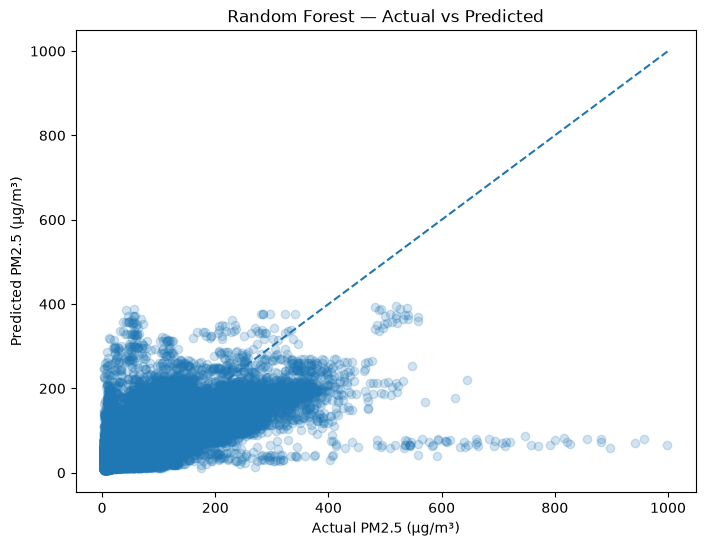

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    y_validation_pred,
    alpha=0.2
)

min_value = min(
    y_validation.min(),
    y_validation_pred.min()
)

max_value = max(
    y_validation.max(),
    y_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Random Forest — Actual vs Predicted")
plt.show()

We can see that random forest improved the prediction but much less than expected. Compared to the model 1 of linear regression, we have 18.5% of improvement for mae, 5.6% for rmse and 0.071 for R2.
Also we can observe the fact that random forest isn't predicting negative values, and can reach higher values (394 vs 250 for the linear model 1)

Model 2:

In [19]:
from src.preprocessing import X_train_pollution, X_validation_pollution, X_test_pollution, y_train_pollution, y_validation_pollution, y_test_pollution
random_forest_pollution = train_model(X_train_pollution,y_train_pollution)
y_pollution_validation_pred, mae_pollution, rmse_pollution, r2_pollution = evaluate_model(random_forest_pollution,X_validation_pollution, y_validation_pollution)

In [20]:
print("Validation MAE:", mae_pollution)
print("Validation RMSE:", rmse_pollution)
print("Validation R²:", r2_pollution)
print(
    "Actual PM2.5 range:",
    y_validation_pollution.min(),
    "→",
    y_validation_pollution.max()
)

print(
    "Predicted PM2.5 range:",
    y_pollution_validation_pred.min(),
    "→",
    y_pollution_validation_pred.max()
)

Validation MAE: 12.897036130506148
Validation RMSE: 21.803540867709792
Validation R²: 0.9011815493030064
Actual PM2.5 range: 3.0 → 821.0
Predicted PM2.5 range: 4.075182179363492 → 661.304379797705


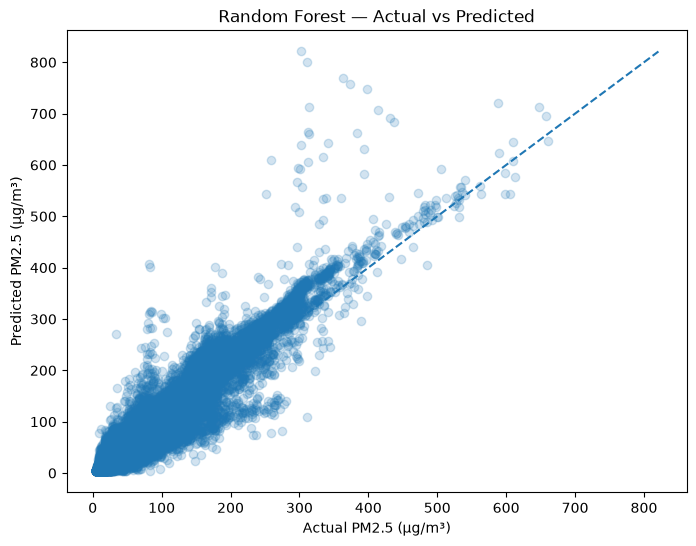

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pollution_validation_pred,
    y_validation_pollution,
    alpha=0.2
)

min_value = min(
    y_pollution_validation_pred.min(),
    y_validation_pollution.min()
)

max_value = max(
    y_pollution_validation_pred.max(),
    y_validation_pollution.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Random Forest — Actual vs Predicted")
plt.show()

The model 2 had really good results. Random forest improved the pollution model by the following: 
- -30% mae
- -21.7% rmse
- +0.62 for R2

Controlled comparison of the 2 model on the same restrictive data set (the one of model 2):

model 1:

In [22]:
from src.preprocessing import X_train_common, X_validation_common, y_train_common, y_validation_common, X_train_common_pollution, X_validation_common_pollution, y_train_common_pollution, y_validation_common_pollution
random_forest_weather_common = train_model(X_train_common,y_train_common)
y_weather_validation,mae_weather_common,rmse_weather_common,r2_weather_common = evaluate_model(random_forest_weather_common,X_validation_common,y_validation_common)

In [23]:
print("Weather-only model:")
print("MAE:", mae_weather_common)
print("RMSE:", rmse_weather_common)
print("R²:", r2_weather_common)
print((
    "Predicted PM2.5 range:",
    y_weather_validation.min(),
    "→",
    y_weather_validation.max()
))

Weather-only model:
MAE: 33.511139314601124
RMSE: 51.83768799275582
R²: 0.44143305552775924
('Predicted PM2.5 range:', np.float64(5.203085818500085), '→', np.float64(365.99405047268357))


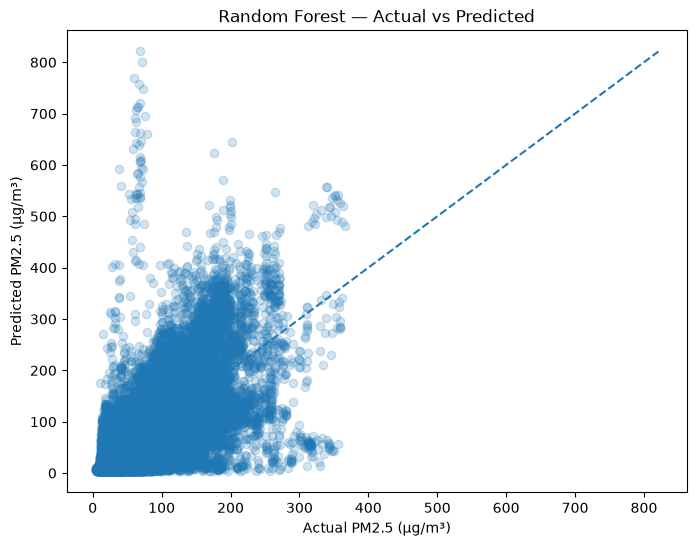

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_weather_validation,
    y_validation_common,
    alpha=0.2
)

min_value = min(
    y_weather_validation.min(),
    y_validation_common.min()
)

max_value = max(
    y_weather_validation.max(),
    y_validation_common.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Random Forest — Actual vs Predicted")
plt.show()

model 2:

In [25]:
random_forest_pollution_common = train_model(X_train_common_pollution,y_train_common_pollution)
y_pollution_validation,mae_pollution_common,rmse_pollution_common,r2_pollution_common = evaluate_model(random_forest_pollution_common,X_validation_common_pollution,y_validation_common_pollution)

In [26]:
print("Weather-pollution model:")
print("MAE:", mae_pollution_common)
print("RMSE:", rmse_pollution_common)
print("R²:", r2_pollution_common)
print((
    "Predicted PM2.5 range:",
    y_pollution_validation_pred.min(),
    "→",
    y_pollution_validation_pred.max()
))

Weather-pollution model:
MAE: 12.897036130506148
RMSE: 21.803540867709792
R²: 0.9011815493030064
('Predicted PM2.5 range:', np.float64(4.075182179363492), '→', np.float64(661.304379797705))


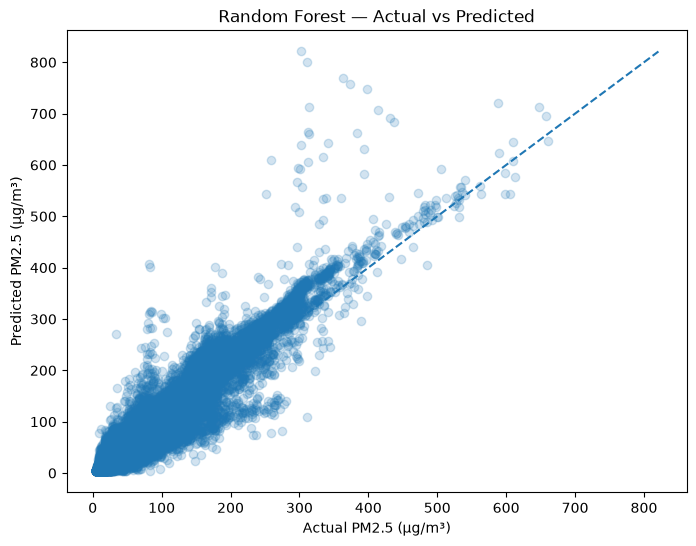

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pollution_validation_pred,
    y_validation_common_pollution,
    alpha=0.2
)

min_value = min(
    y_pollution_validation_pred.min(),
    y_validation_common_pollution.min()
)

max_value = max(
    y_pollution_validation_pred.max(),
    y_validation_common_pollution.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Random Forest — Actual vs Predicted")
plt.show()

Improvements thanks to the pollution features:

In [28]:
rmse_improvement = (
    (rmse_weather_common - rmse_pollution_common)
    / rmse_weather_common
    * 100
)

mae_improvement = (
    (mae_weather_common - mae_pollution_common)
    / mae_weather_common
    * 100
)

print("RMSE improvement:", rmse_improvement, "%")
print("MAE improvement:", mae_improvement, "%")
print(
    "R² improvement:",
    r2_pollution_common - r2_weather_common
)

RMSE improvement: 57.93882460429798 %
MAE improvement: 61.51418186821602 %
R² improvement: 0.4597484937752472


XGBOOST

model 1:

In [29]:
from src.load_data import load_data
from src.preprocessing import X_train, X_validation, X_test, y_train, y_validation, y_test
from models.xgboost import train_model, evaluate_model
xgboost = train_model(X_train,y_train)
y_validation_pred,mae, rmse, r2 = evaluate_model(xgboost,X_validation,y_validation)


In [30]:
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)
print("Validation R²:", r2)
print(
    "Actual PM2.5 range:",
    y_validation.min(),
    "→",
    y_validation.max()
)

print(
    "Predicted PM2.5 range:",
    y_validation_pred.min(),
    "→",
    y_validation_pred.max()
)

Validation MAE: 33.08858951470117
Validation RMSE: 51.56329810976008
Validation R²: 0.4610614931939885
Actual PM2.5 range: 3.0 → 999.0
Predicted PM2.5 range: -22.057192 → 317.987


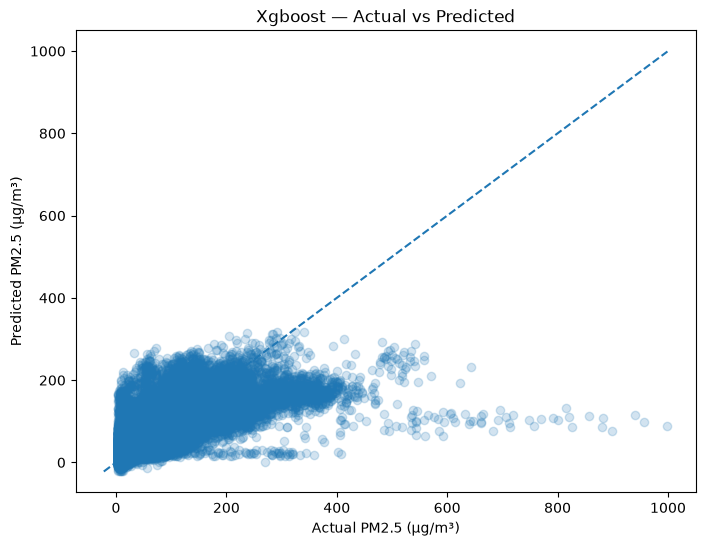

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    y_validation_pred,
    alpha=0.2
)

min_value = min(
    y_validation.min(),
    y_validation_pred.min()
)

max_value = max(
    y_validation.max(),
    y_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Xgboost — Actual vs Predicted")
plt.show()

model 2:

In [32]:
from src.preprocessing import X_train_pollution, X_validation_pollution, X_test_pollution, y_train_pollution, y_validation_pollution, y_test_pollution
xgboost_pollution = train_model(X_train_pollution,y_train_pollution)
y_pollution_validation_pred, mae_pollution, rmse_pollution, r2_pollution = evaluate_model(xgboost_pollution,X_validation_pollution, y_validation_pollution)

In [33]:
print("Validation MAE:", mae_pollution)
print("Validation RMSE:", rmse_pollution)
print("Validation R²:", r2_pollution)
print(
    "Actual PM2.5 range:",
    y_validation_pollution.min(),
    "→",
    y_validation_pollution.max()
)

print(
    "Predicted PM2.5 range:",
    y_pollution_validation_pred.min(),
    "→",
    y_pollution_validation_pred.max()
)

Validation MAE: 12.242965307540166
Validation RMSE: 21.073039031646722
Validation R²: 0.9076922155379088
Actual PM2.5 range: 3.0 → 821.0
Predicted PM2.5 range: -0.8002519 → 552.11005


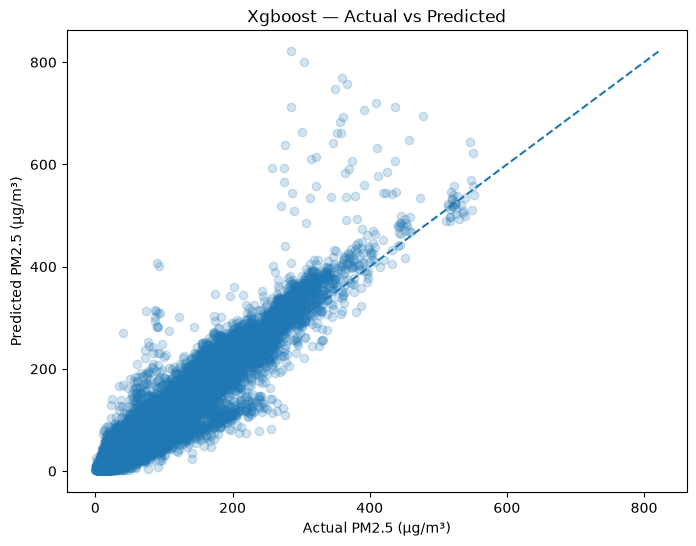

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pollution_validation_pred,
    y_validation_pollution,
    alpha=0.2
)

min_value = min(
    y_pollution_validation_pred.min(),
    y_validation_pollution.min()
)

max_value = max(
    y_pollution_validation_pred.max(),
    y_validation_pollution.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Xgboost — Actual vs Predicted")
plt.show()

Xgboost had better performances than random forest on his dataset. 
The rmse decreased by 3.35%, the mae by 5.11% and the R2 increased by 0.0065. However we have diminishing returns showing us that Random Forest was already capturing most of the nonlinear structure available in these features. We also now have negative prediction which is physically impossible. We also have lower upper bound for the predictions compared to Random Forest.

FEATURE IMPORTANCE SECTION

We now saw that Xgboost + pollution & weather features is the best model so far. We will perform a feature importance analysis to understand which feature is driving the alpha.

In [41]:
#we label the columns of X_train_pollution
from src.preprocessing import encoder, categorical_features, numerical_features_pollution
categorical_feature_names = encoder.get_feature_names_out(
    categorical_features
)
print(categorical_feature_names)
feature_names = list(numerical_features_pollution) + list(categorical_feature_names)
print(feature_names)

['wd_E' 'wd_ENE' 'wd_ESE' 'wd_N' 'wd_NE' 'wd_NNE' 'wd_NNW' 'wd_NW' 'wd_S'
 'wd_SE' 'wd_SSE' 'wd_SSW' 'wd_SW' 'wd_W' 'wd_WNW' 'wd_WSW'
 'station_Aotizhongxin' 'station_Changping' 'station_Dingling'
 'station_Dongsi' 'station_Guanyuan' 'station_Gucheng' 'station_Huairou'
 'station_Nongzhanguan' 'station_Shunyi' 'station_Tiantan'
 'station_Wanliu' 'station_Wanshouxigong']
['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'wd_E', 'wd_ENE', 'wd_ESE', 'wd_N', 'wd_NE', 'wd_NNE', 'wd_NNW', 'wd_NW', 'wd_S', 'wd_SE', 'wd_SSE', 'wd_SSW', 'wd_SW', 'wd_W', 'wd_WNW', 'wd_WSW', 'station_Aotizhongxin', 'station_Changping', 'station_Dingling', 'station_Dongsi', 'station_Guanyuan', 'station_Gucheng', 'station_Huairou', 'station_Nongzhanguan', 'station_Shunyi', 'station_Tiantan', 'station_Wanliu', 'station_Wanshouxigong']


In [43]:
#sanity check
print("Number of features names;", len(feature_names))
print("Number of X columns:",X_train_pollution.shape[1])

Number of features names; 44
Number of X columns: 44


In [45]:
#we ask xgboost for importance
importance = xgboost_pollution.get_booster().get_score(importance_type="gain")
print(importance)
#we convert the f"x" into their real names
importance_dict = {}
for feature, value in importance.items():
    index = int(feature[1:])
    feature_name = feature_names[index]
    importance_dict[feature_name] = value

{'f0': 35455.5546875, 'f1': 22644.599609375, 'f2': 97210.171875, 'f3': 24158.06640625, 'f4': 29665.44140625, 'f5': 26210.263671875, 'f6': 26694.53515625, 'f7': 50380.80078125, 'f8': 156868.6875, 'f9': 23348.681640625, 'f10': 25453.900390625, 'f11': 2444759.25, 'f12': 42228.31640625, 'f13': 141040.03125, 'f14': 1170394.125, 'f15': 36946.12109375, 'f16': 8460.5126953125, 'f17': 11900.0537109375, 'f18': 9392.173828125, 'f19': 8725.705078125, 'f20': 6068.029296875, 'f21': 6714.994140625, 'f22': 8189.12890625, 'f23': 7363.4033203125, 'f24': 5060.2314453125, 'f25': 13717.798828125, 'f26': 16565.404296875, 'f27': 6995.353515625, 'f28': 14076.02734375, 'f29': 9191.2119140625, 'f30': 9014.0654296875, 'f31': 5450.3681640625, 'f32': 23237.271484375, 'f33': 25503.763671875, 'f34': 79225.203125, 'f35': 17776.865234375, 'f36': 12330.322265625, 'f37': 38877.1328125, 'f38': 23742.962890625, 'f39': 14588.568359375, 'f40': 14572.4970703125, 'f41': 11321.9873046875, 'f42': 23312.267578125, 'f43': 55247.3

In [47]:
import pandas as pd
importance_df = pd.DataFrame({"feature": importance_dict.keys(),
                             "importance": importance_dict.values()})
print(importance_df)

                  feature    importance
0                    TEMP  3.545555e+04
1                    PRES  2.264460e+04
2                    DEWP  9.721017e+04
3                    RAIN  2.415807e+04
4                    WSPM  2.966544e+04
5                hour_sin  2.621026e+04
6                hour_cos  2.669454e+04
7               month_sin  5.038080e+04
8               month_cos  1.568687e+05
9         day_of_week_sin  2.334868e+04
10        day_of_week_cos  2.545390e+04
11                   PM10  2.444759e+06
12                    SO2  4.222832e+04
13                    NO2  1.410400e+05
14                     CO  1.170394e+06
15                     O3  3.694612e+04
16                   wd_E  8.460513e+03
17                 wd_ENE  1.190005e+04
18                 wd_ESE  9.392174e+03
19                   wd_N  8.725705e+03
20                  wd_NE  6.068029e+03
21                 wd_NNE  6.714994e+03
22                 wd_NNW  8.189129e+03
23                  wd_NW  7.363403e+03


In [51]:
#we organize the ranking
importance_df = importance_df.sort_values("importance", ascending=False)
print(importance_df.head(10))

                  feature    importance
11                   PM10  2.444759e+06
14                     CO  1.170394e+06
8               month_cos  1.568687e+05
13                    NO2  1.410400e+05
2                    DEWP  9.721017e+04
34       station_Dingling  7.922520e+04
43  station_Wanshouxigong  5.524736e+04
7               month_sin  5.038080e+04
12                    SO2  4.222832e+04
37        station_Gucheng  3.887713e+04


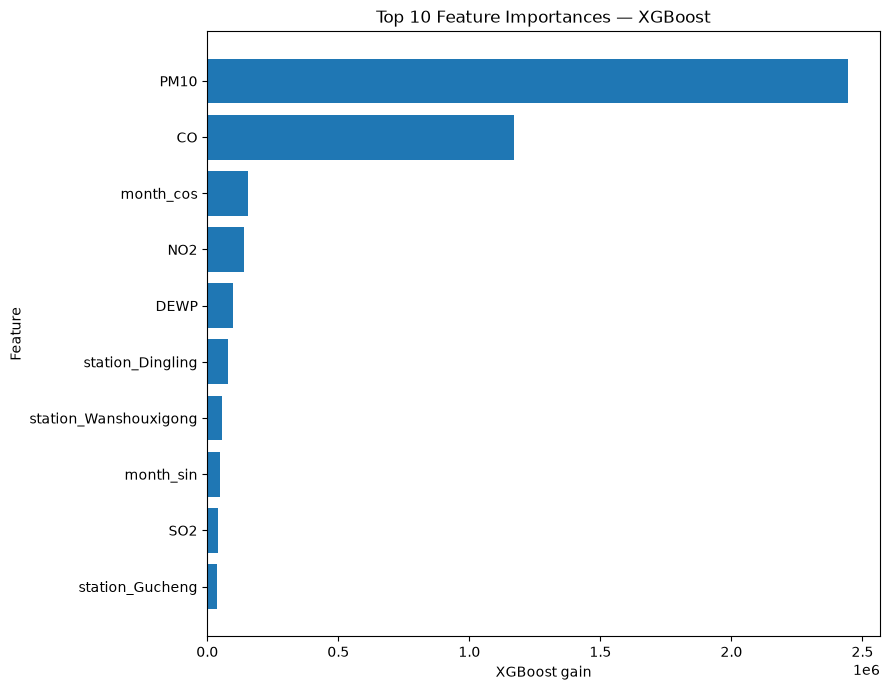

In [52]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10).sort_values(
    "importance"
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("XGBoost gain")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — XGBoost")

plt.tight_layout()
plt.show()

FINE TUNE SECTION

 We will now perform fine tuning with respect to the validation dataset. 

In [39]:
param_grid = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

In [54]:
from sklearn.model_selection import TimeSeriesSplit
from itertools import product
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
n_combinations = np.prod([
    len(values)
    for values in param_grid.values()
])
print("Number of combinations:", n_combinations)

Number of combinations: 324


In [55]:
param_names = list(param_grid.keys())
param_combinations = list(product(*param_grid.values()))
print(len(param_combinations))

324


In [56]:
results = []

for combination in param_combinations:

    params = dict(zip(param_names, combination))

    model = XGBRegressor(
        **params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_pollution,
        y_train_pollution
    )

    y_pred = model.predict(
        X_validation_pollution
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation_pollution,
            y_pred
        )
    )

    results.append({
        **params,
        "rmse": rmse
    })
results_df = pd.DataFrame(results)
print(results_df.head())

   n_estimators  learning_rate  max_depth  min_child_weight  subsample  \
0           300           0.03          3                 1        0.8   
1           300           0.03          3                 1        0.8   
2           300           0.03          3                 1        1.0   
3           300           0.03          3                 1        1.0   
4           300           0.03          3                 5        0.8   

   colsample_bytree       rmse  
0               0.8  22.894267  
1               1.0  22.862161  
2               0.8  23.074761  
3               1.0  22.868268  
4               0.8  22.894094  


In [59]:
best_result = results_df.sort_values(
    "rmse"
).iloc[0]
print(best_result)
#analysing if there is a clear winner: 
print("The 10 best results:",results_df.sort_values(
    "rmse"
).head(10))
results_df.to_csv(
    "xgboost_grid_search_results.csv",
    index=False
)

n_estimators        800.000000
learning_rate         0.100000
max_depth             3.000000
min_child_weight      5.000000
subsample             1.000000
colsample_bytree      1.000000
rmse                 20.456009
Name: 295, dtype: float64
The 10 best results:      n_estimators  learning_rate  max_depth  min_child_weight  subsample  \
295           800           0.10          3                 5        1.0   
293           800           0.10          3                 5        0.8   
284           800           0.05          7                10        0.8   
289           800           0.10          3                 1        0.8   
249           800           0.03          7                10        0.8   
286           800           0.05          7                10        1.0   
308           800           0.10          5                10        0.8   
309           800           0.10          5                10        0.8   
210           500           0.10          7         

In [60]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
best_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.10,
    max_depth=3,
    min_child_weight=5,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

best_model.fit(
    X_train_pollution,
    y_train_pollution
)
y_validation_pred_best = best_model.predict(
    X_validation_pollution
)
mae_best = mean_absolute_error(
    y_validation_pollution,
    y_validation_pred_best
)

rmse_best = np.sqrt(
    mean_squared_error(
        y_validation_pollution,
        y_validation_pred_best
    )
)

r2_best = r2_score(
    y_validation_pollution,
    y_validation_pred_best
)

print("Validation MAE:", mae_best)
print("Validation RMSE:", rmse_best)
print("Validation R²:", r2_best)

print(
    "Actual PM2.5 range:",
    y_validation_pollution.min(),
    "→",
    y_validation_pollution.max()
)

print(
    "Predicted PM2.5 range:",
    y_validation_pred_best.min(),
    "→",
    y_validation_pred_best.max()
)

Validation MAE: 12.7099077473611
Validation RMSE: 20.456009125909624
Validation R²: 0.9130187185263938
Actual PM2.5 range: 3.0 → 821.0
Predicted PM2.5 range: -6.3489866 → 623.53766


With the grid search, we inproved the RMSE by 2.93%.
The winning combination is the following: n_estimators   =     800
learning_rate     =  0.1
max_depth       =     3
min_child_weight  =     5
subsample       =      1
colsample_bytree    =  1

With a rmse = 20.456009

We can also notice that for the 8 best combination, xgboost use the maximum number of trees (800). We might want to test a new grid search with higher number of trees.

We run a new small grid search, focusing on N_estimators to see if a upper boundary is better.

In [66]:
n_estimators_values = np.linspace(800,1500,15,dtype=int)

results_n_estimators = []
for n_estimators in n_estimators_values:

    print(f"Training model with {n_estimators} trees...")

    model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=0.10,
        max_depth=3,
        min_child_weight=5,
        subsample=1.0,
        colsample_bytree=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_pollution,
        y_train_pollution
    )

    y_pred = model.predict(
        X_validation_pollution
    )

    mae = mean_absolute_error(
        y_validation_pollution,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation_pollution,
            y_pred
        )
    )

    r2 = r2_score(
        y_validation_pollution,
        y_pred
    )

    results_n_estimators.append({
        "n_estimators": n_estimators,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    print(
        f"MAE: {mae:.3f} | "
        f"RMSE: {rmse:.3f} | "
        f"R²: {r2:.3f}"
    )

Training model with 800 trees...
MAE: 12.710 | RMSE: 20.456 | R²: 0.913
Training model with 850 trees...
MAE: 12.674 | RMSE: 20.396 | R²: 0.914
Training model with 900 trees...
MAE: 12.635 | RMSE: 20.350 | R²: 0.914
Training model with 950 trees...
MAE: 12.598 | RMSE: 20.277 | R²: 0.915
Training model with 1000 trees...
MAE: 12.550 | RMSE: 20.187 | R²: 0.915
Training model with 1050 trees...
MAE: 12.527 | RMSE: 20.130 | R²: 0.916
Training model with 1100 trees...
MAE: 12.503 | RMSE: 20.108 | R²: 0.916
Training model with 1150 trees...
MAE: 12.490 | RMSE: 20.087 | R²: 0.916
Training model with 1200 trees...
MAE: 12.476 | RMSE: 20.082 | R²: 0.916
Training model with 1250 trees...
MAE: 12.464 | RMSE: 20.069 | R²: 0.916
Training model with 1300 trees...
MAE: 12.445 | RMSE: 20.043 | R²: 0.916
Training model with 1350 trees...
MAE: 12.433 | RMSE: 20.031 | R²: 0.917
Training model with 1400 trees...
MAE: 12.429 | RMSE: 20.040 | R²: 0.917
Training model with 1450 trees...
MAE: 12.416 | RMSE: 2

In [67]:
results_n_estimators_df = pd.DataFrame(
    results_n_estimators
)

best_n_estimators = results_n_estimators_df.loc[
    results_n_estimators_df["RMSE"].idxmin()
]

print(best_n_estimators)

n_estimators    1500.000000
MAE               12.409550
RMSE              20.004425
R²                 0.916817
Name: 14, dtype: float64


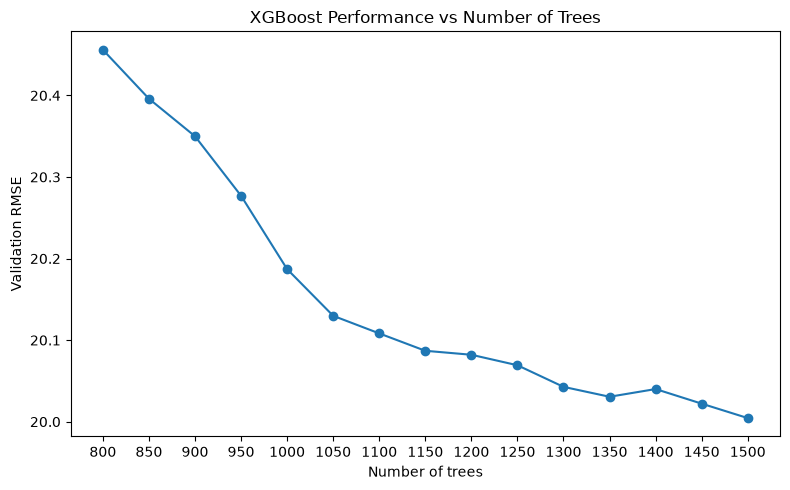

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_n_estimators_df["n_estimators"],
    results_n_estimators_df["RMSE"],
    marker="o"
)

plt.xlabel("Number of trees")
plt.ylabel("Validation RMSE")
plt.title("XGBoost Performance vs Number of Trees")

plt.xticks(n_estimators_values)

plt.tight_layout()
plt.show()

We hit again the upper boundary. Instead of doing a new grid search, let's introduce early stopping for the number of tree created.

In [73]:
model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.10,
    max_depth=3,
    min_child_weight=5,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=200
)
#if the validation metric doesn't improve for 200 consecutive boosting rounds, we stop the training
model.fit(
    X_train_pollution,
    y_train_pollution,
    eval_set=[(X_validation_pollution, y_validation_pollution)],
    verbose=False
)
print("Best iteration:", model.best_iteration)
print("Best score:", model.best_score)

Best iteration: 1544
Best score: 19.992671370744468


The model benefited from additional boosting rounds beyond the 800 trees found in the initial grid search, but validation performance stopped improving after approximately 1,544 boosting iterations.

In [74]:
y_validation_pred_final = model.predict(
    X_validation_pollution
)

mae_final = mean_absolute_error(
    y_validation_pollution,
    y_validation_pred_final
)

rmse_final = np.sqrt(
    mean_squared_error(
        y_validation_pollution,
        y_validation_pred_final
    )
)

r2_final = r2_score(
    y_validation_pollution,
    y_validation_pred_final
)

print("Validation MAE:", mae_final)
print("Validation RMSE:", rmse_final)
print("Validation R²:", r2_final)

print(
    "Actual PM2.5 range:",
    y_validation_pollution.min(),
    "→",
    y_validation_pollution.max()
)

print(
    "Predicted PM2.5 range:",
    y_validation_pred_final.min(),
    "→",
    y_validation_pred_final.max()
)

Validation MAE: 12.399745208365095
Validation RMSE: 19.992671369698023
Validation R²: 0.9169144232697862
Actual PM2.5 range: 3.0 → 821.0
Predicted PM2.5 range: -15.6716795 → 639.4121


Now we will stop the fine tuning to not over specialize the model to our validation set.
We will now proceed to the test set evaluation.

In [75]:
#the final model:
y_test_pred = model.predict(
    X_test_pollution
)
mae_test = mean_absolute_error(
    y_test_pollution,
    y_test_pred
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test_pollution,
        y_test_pred
    )
)

r2_test = r2_score(
    y_test_pollution,
    y_test_pred
)

print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)
print("Test R²:", r2_test)
print(
    "Actual PM2.5 range:",
    y_test_pollution.min(),
    "→",
    y_test_pollution.max()
)

print(
    "Predicted PM2.5 range:",
    y_test_pred.min(),
    "→",
    y_test_pred.max()
)

Test MAE: 12.636578992357004
Test RMSE: 19.893930527239846
Test R²: 0.9494320224921804
Actual PM2.5 range: 2.0 → 835.0
Predicted PM2.5 range: -71.86348 → 663.74615


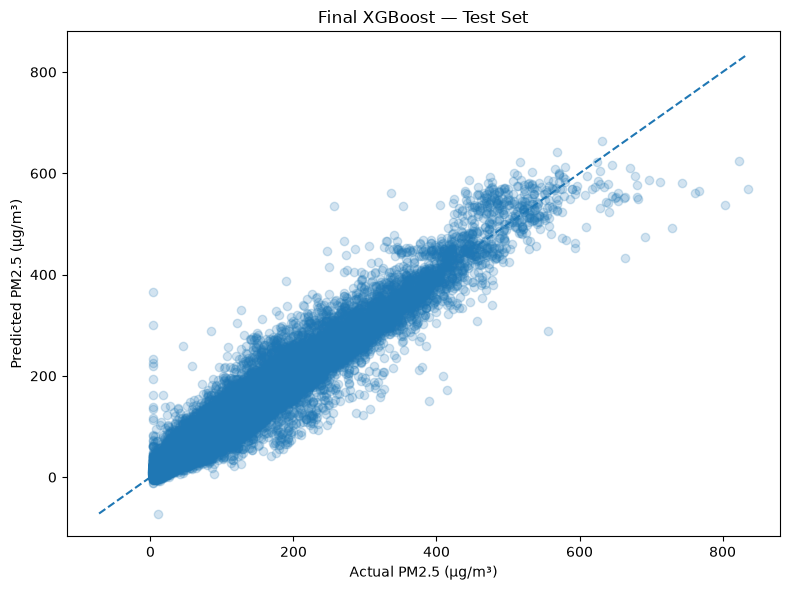

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pollution,
    y_test_pred,
    alpha=0.2
)

min_value = min(
    y_test_pollution.min(),
    y_test_pred.min()
)

max_value = max(
    y_test_pollution.max(),
    y_test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Final XGBoost — Test Set")

plt.tight_layout()
plt.show()

We also proceed to a plot with data inferior to 300

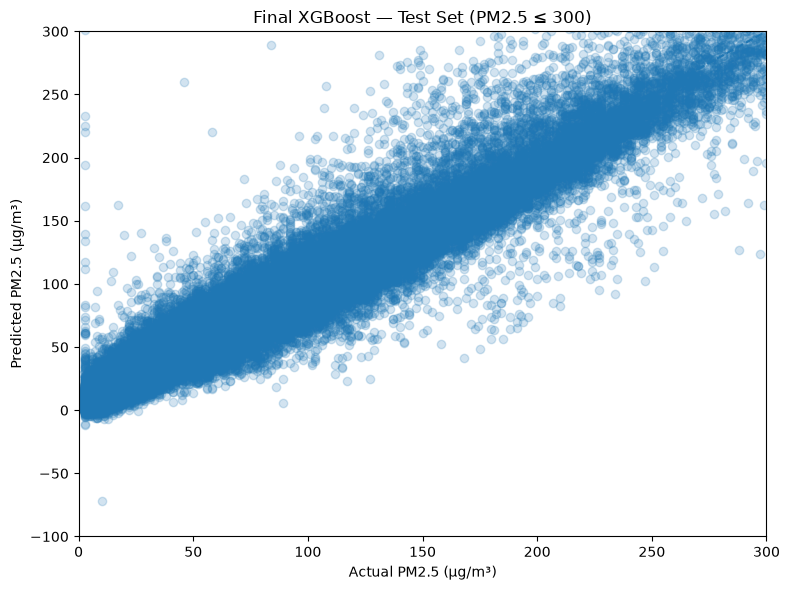

In [79]:
mask = y_test_pollution <= 300

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pollution[mask],
    y_test_pred[mask],
    alpha=0.2
)

plt.plot(
    [0, 300],
    [0, 300],
    linestyle="--"
)

plt.xlim(0, 300)
plt.ylim(-100, 300)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Final XGBoost — Test Set (PM2.5 ≤ 300)")

plt.tight_layout()
plt.show()

We can observe slightly better results with the test set compared to the validation set. However we still have negative values predicted which has no physical senses.

Residuals analysis:

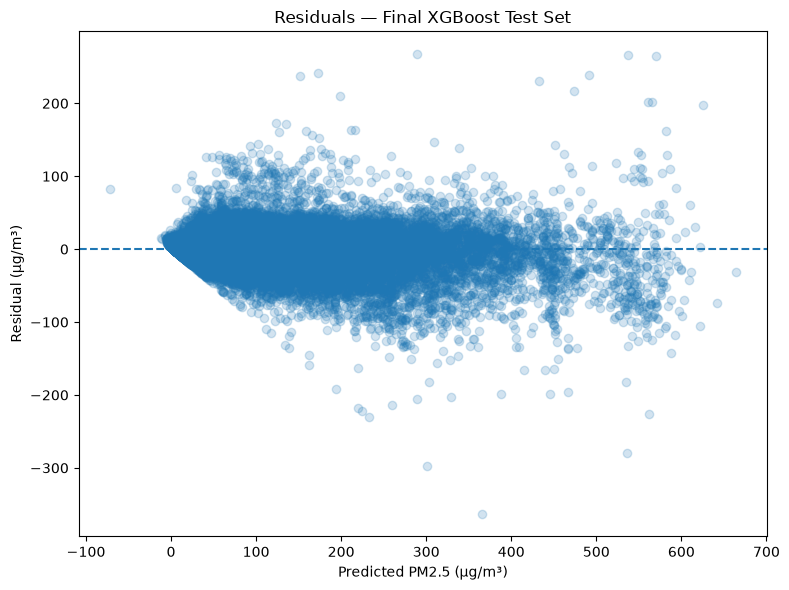

In [80]:
residuals = (
    y_test_pollution - y_test_pred
)
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted PM2.5 (µg/m³)")
plt.ylabel("Residual (µg/m³)")
plt.title("Residuals — Final XGBoost Test Set")

plt.tight_layout()
plt.show()

We can observe a residual plot centered on 0. There is no systematic bias where the model consistently over/underpredicts everything. 
We also observe that the residual spread increases as PM2.5 increases.

Error by range :

In [82]:
bins = [
    0,
    50,
    100,
    200,
    300,
    500,
    np.inf
]

labels = [
    "0–50",
    "50–100",
    "100–200",
    "200–300",
    "300–500",
    "500+"
]

test_results = pd.DataFrame({
    "actual": y_test_pollution,
    "predicted": y_test_pred
})

test_results["range"] = pd.cut(
    test_results["actual"],
    bins=bins,
    labels=labels,
    right=False
)
error_by_range = (
    test_results
    .groupby("range", observed=True)
    .apply(
        lambda x: mean_absolute_error(
            x["actual"],
            x["predicted"]
        )
    )
)

print("Error by range:",error_by_range)

rmse_by_range = (
    test_results
    .groupby("range", observed=True)
    .apply(
        lambda x: np.sqrt(
            mean_squared_error(
                x["actual"],
                x["predicted"]
            )
        )
    )
)

print("RMSE by range:",rmse_by_range)

Error by range: range
0–50        7.314998
50–100     12.748688
100–200    18.400347
200–300    22.593712
300–500    30.896171
500+       45.747444
dtype: float64
RMSE by range: range
0–50       11.352608
50–100     17.117112
100–200    25.481499
200–300    31.951818
300–500    42.432962
500+       68.185804
dtype: float64


We can here observe a clear pattern. For both MAE and RMSE, the more PM2.5 are extreme, the more the error increases. This is demonstrated by the range of the prediction: The model doesn't reach the highest observed PM2.5 values.

Final experiment: Does predicting log(1 + PM2.5) give us a better-behaved model while naturally avoiding negative PM2.5 predictions?

In [83]:
import numpy as np
y_train_log = np.log1p(y_train_pollution)
y_validation_log = np.log1p(y_validation_pollution)

In [84]:
from xgboost import XGBRegressor

log_model = XGBRegressor(
    n_estimators=1544,
    learning_rate=0.10,
    max_depth=3,
    min_child_weight=5,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
log_model.fit(
    X_train_pollution,
    y_train_log
)
y_validation_pred_log = log_model.predict(
    X_validation_pollution
)
y_validation_pred_log = log_model.predict(
    X_validation_pollution
)

y_validation_pred = np.expm1(
    y_validation_pred_log
)
print(
    "Predicted PM2.5 range:",
    y_validation_pred.min(),
    "→",
    y_validation_pred.max()
)

Predicted PM2.5 range: 0.9675347 → 562.2357


In [85]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_log_model = mean_absolute_error(
    y_validation_pollution,
    y_validation_pred
)

rmse_log_model = np.sqrt(
    mean_squared_error(
        y_validation_pollution,
        y_validation_pred
    )
)

r2_log_model = r2_score(
    y_validation_pollution,
    y_validation_pred
)

print("Validation MAE:", mae_log_model)
print("Validation RMSE:", rmse_log_model)
print("Validation R²:", r2_log_model)

Validation MAE: 12.732494586993461
Validation RMSE: 21.986957138544536
Validation R²: 0.8995119904697826


We obtained worse results compared to our original model. This can be explained by the fact that our log(1+y) target has compressed the large PM2.5 concentration. Consequently, the model pays relatively less attention to absolute errors during severe pollution events.

So for the inference part of the project, lets keep the final raw XGBoost model. 

We save the model

In [97]:
from pathlib import Path
project_root = Path.cwd().parent
MODEL_PATH = project_root / "models" / "saved" / "xgboost_pollution.json"
MODEL_PATH.parent.mkdir(parents=True,exist_ok=True)
model.save_model(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

Model saved to: /Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction/models/saved/xgboost_pollution.json


And we test that it loads well

In [100]:
from xgboost import XGBRegressor

loaded_model = XGBRegressor()
loaded_model.load_model(
    MODEL_PATH
)
pred = loaded_model.predict(
    X_validation_pollution[:5]
)

print(pred)
original_pred = model.predict(
    X_validation_pollution[:5]
)

print(original_pred)
print(
    np.allclose(pred, original_pred)
)

[240.98033 240.88544 188.6648  158.18288 124.54025]
[240.98033 240.88544 188.6648  158.18288 124.54025]
True


In [3]:
from src.api import get_weather

latitude = 39.9042
longitude = 116.4074

weather = get_weather(
    latitude,
    longitude
)

weather
from src.api import get_air_quality

air_quality = get_air_quality(
    latitude,
    longitude
)

print(air_quality["current"])

{'time': '2026-08-16T01:00', 'interval': 3600, 'pm10': 154.1, 'carbon_monoxide': 1559.0, 'nitrogen_dioxide': 131.8, 'sulphur_dioxide': 14.2, 'ozone': 1.0}


In [4]:
from src.api import get_weather, get_air_quality, create_api_features
features = create_api_features(weather,air_quality)
print(features)

{'TEMP': 24.5, 'PRES': 999.0, 'DEWP': 22.0, 'RAIN': 0.0, 'WSPM': 1.03, 'wd': 'SSE', 'PM10': 154.1, 'CO': 1559.0, 'NO2': 131.8, 'SO2': 14.2, 'O3': 1.0}
